<a href="https://colab.research.google.com/github/nguyen23012007/MY_PROJECT/blob/main/BTVNFACEIDDN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU

# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/File ảnh lớp"

# Kích thước ảnh và kích thước lô
img_width, img_height = 128, 128
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255,      # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(train_generator.num_classes, activation="softmax") # Corrected to match the number of classes in the training data
])

Found 2236 images belonging to 38 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 314ms/step - accuracy: 0.8211 - loss: 0.6126
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.8171 - loss: 0.6135
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.8193 - loss: 0.6230
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.8265 - loss: 0.5985
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 270ms/step - accuracy: 0.8359 - loss: 0.5559
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step - accuracy: 0.8296 - loss: 0.5980
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 293ms/step - accuracy: 0.8309 - loss: 0.5840
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.8457 - loss: 0.5293
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.8542 - loss: 0.5235
Epoch 10/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 284ms/step - accuracy: 0.8623 - loss: 0.4653
Validation accuracy was not calculated as `validation_generator` was not provided or set to None.


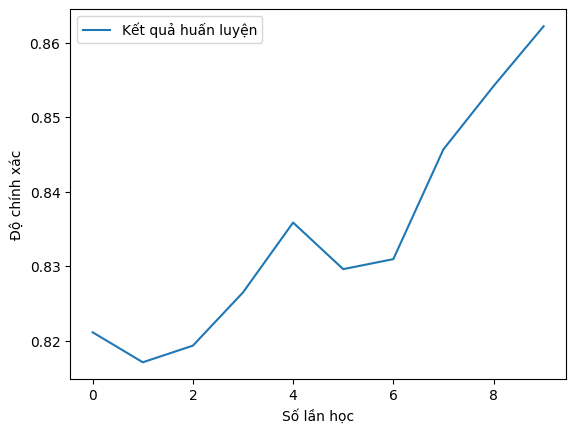

In [117]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 10

# The 'validation_generator' is not defined, leading to a NameError.
# For a proper validation setup, you should define a separate `validation_datagen`
# and `validation_generator` pointing to a distinct validation dataset directory,
# or by using `validation_split` with your `train_datagen` in a previous cell
# and creating two generators (training and validation) from it.
#
# As a temporary fix to prevent the NameError and allow this cell to execute,
# `validation_generator` is being set to `None`.
# This means the model will be trained without a validation set, and `val_accuracy`
# will not be computed or available for plotting.
validation_generator = None

# Bắt buộc phải thêm validation_data vào đây để sinh ra 'val_accuracy'
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")

# Conditionally plot validation accuracy if it's available
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
else:
    print("Validation accuracy was not calculated as `validation_generator` was not provided or set to None.")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---


Saving Screenshot 2026-05-27 090519.png to Screenshot 2026-05-27 090519 (9).png


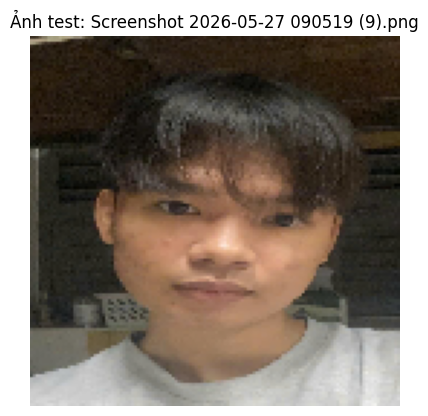

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
------------------------------
Người dự đoán: Danh Nguyên
Độ chính xác: 72.99%
------------------------------


In [132]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from google.colab import files # Cần import thêm thư viện này

# 1. Hiển thị nút "Chọn Tệp" để tải ảnh lên máy chủ tạm thời
print("--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---")
uploaded = files.upload()

# 2. Xử lý ảnh vừa tải (Chương trình sẽ tự động lấy tên file ảnh)
if not uploaded:
    print("Bạn chưa tải ảnh nào lên.")
else:
    # Lấy tên của tệp ảnh đầu tiên được tải lên (nếu tải nhiều ảnh một lúc)
    filename = list(uploaded.keys())[0]
    path = filename # Đường dẫn bây giờ chính là tên file

    # 3. Tiền xử lý (Giữ nguyên logic cũ nhưng gọn hơn)
    img_width, img_height = 128, 128 # Đảm bảo kích thước khớp với lúc train

    # Tải ảnh và hiển thị
    img_load = load_img(path, target_size=(img_width, img_height))
    plt.imshow(img_load)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title(f"Ảnh test: {filename}")
    plt.show()

    # Chuẩn hóa ảnh
    img_array = img_to_array(img_load)
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, img_width, img_height, 3)

    # 4. Chạy dự đoán và lấy xác suất cao nhất
    predictions = model.predict(img_array)
    prediction_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100 # Chuyển sang %

    # 5. Ánh xạ loại tới tên người (Yêu cầu `train_generator` phải tồn tại)
    if 'train_generator' in locals() or 'train_generator' in globals():
        class_labels = {v: k for k, v in train_generator.class_indices.items()}
        person_name = class_labels[prediction_index]

        # In kết quả
        print("-" * 30)
        print(f"Người dự đoán: {person_name}")
        print(f"Độ chính xác: {confidence:.2f}%")
        print("-" * 30)
    else:
        print("Lỗi: Không tìm thấy 'train_generator' để lấy nhãn lớp. Đảm bảo bạn đã chạy code huấn luyện trước.")

--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---


Saving z7885782699739_933154f7ce5f623fcf3e03863c79dd25.jpg to z7885782699739_933154f7ce5f623fcf3e03863c79dd25.jpg


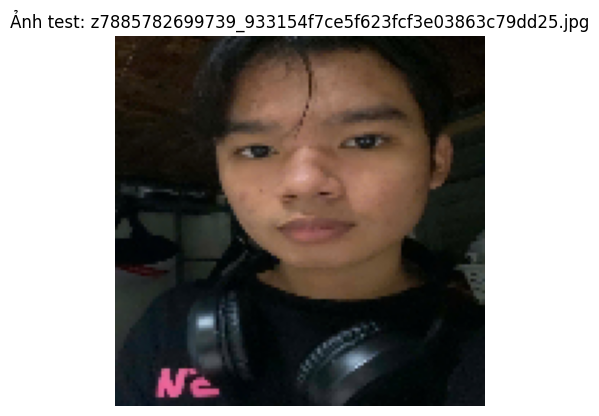

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
------------------------------
Người dự đoán: Danh Nguyên
Độ chính xác: 93.73%
------------------------------


In [141]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from google.colab import files # Cần import thêm thư viện này

# 1. Hiển thị nút "Chọn Tệp" để tải ảnh lên máy chủ tạm thời
print("--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---")
uploaded = files.upload()

# 2. Xử lý ảnh vừa tải (Chương trình sẽ tự động lấy tên file ảnh)
if not uploaded:
    print("Bạn chưa tải ảnh nào lên.")
else:
    # Lấy tên của tệp ảnh đầu tiên được tải lên (nếu tải nhiều ảnh một lúc)
    filename = list(uploaded.keys())[0]
    path = filename # Đường dẫn bây giờ chính là tên file

    # 3. Tiền xử lý (Giữ nguyên logic cũ nhưng gọn hơn)
    img_width, img_height = 128, 128 # Đảm bảo kích thước khớp với lúc train

    # Tải ảnh và hiển thị
    img_load = load_img(path, target_size=(img_width, img_height))
    plt.imshow(img_load)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title(f"Ảnh test: {filename}")
    plt.show()

    # Chuẩn hóa ảnh
    img_array = img_to_array(img_load)
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, img_width, img_height, 3)

    # 4. Chạy dự đoán và lấy xác suất cao nhất
    predictions = model.predict(img_array)
    prediction_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100 # Chuyển sang %

    # 5. Ánh xạ loại tới tên người (Yêu cầu `train_generator` phải tồn tại)
    if 'train_generator' in locals() or 'train_generator' in globals():
        class_labels = {v: k for k, v in train_generator.class_indices.items()}
        person_name = class_labels[prediction_index]

        # In kết quả
        print("-" * 30)
        print(f"Người dự đoán: {person_name}")
        print(f"Độ chính xác: {confidence:.2f}%")
        print("-" * 30)
    else:
        print("Lỗi: Không tìm thấy 'train_generator' để lấy nhãn lớp. Đảm bảo bạn đã chạy code huấn luyện trước.")

--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---


Saving Screenshot 2026-05-31 160008.png to Screenshot 2026-05-31 160008 (8).png


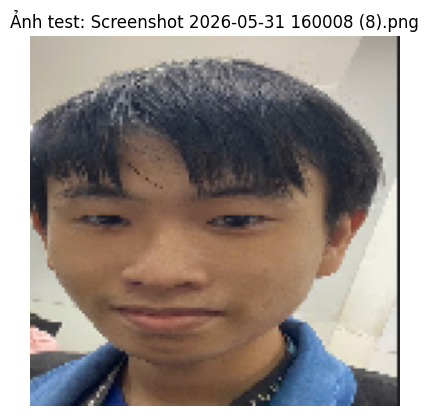

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
------------------------------
Người dự đoán: Trần Anh Khôi 
Độ chính xác: 68.66%
------------------------------


In [135]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from google.colab import files # Cần import thêm thư viện này

# 1. Hiển thị nút "Chọn Tệp" để tải ảnh lên máy chủ tạm thời
print("--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---")
uploaded = files.upload()

# 2. Xử lý ảnh vừa tải (Chương trình sẽ tự động lấy tên file ảnh)
if not uploaded:
    print("Bạn chưa tải ảnh nào lên.")
else:
    # Lấy tên của tệp ảnh đầu tiên được tải lên (nếu tải nhiều ảnh một lúc)
    filename = list(uploaded.keys())[0]
    path = filename # Đường dẫn bây giờ chính là tên file

    # 3. Tiền xử lý (Giữ nguyên logic cũ nhưng gọn hơn)
    img_width, img_height = 128, 128 # Đảm bảo kích thước khớp với lúc train

    # Tải ảnh và hiển thị
    img_load = load_img(path, target_size=(img_width, img_height))
    plt.imshow(img_load)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title(f"Ảnh test: {filename}")
    plt.show()

    # Chuẩn hóa ảnh
    img_array = img_to_array(img_load)
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, img_width, img_height, 3)

    # 4. Chạy dự đoán và lấy xác suất cao nhất
    predictions = model.predict(img_array)
    prediction_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100 # Chuyển sang %

    # 5. Ánh xạ loại tới tên người (Yêu cầu `train_generator` phải tồn tại)
    if 'train_generator' in locals() or 'train_generator' in globals():
        class_labels = {v: k for k, v in train_generator.class_indices.items()}
        person_name = class_labels[prediction_index]

        # In kết quả
        print("-" * 30)
        print(f"Người dự đoán: {person_name}")
        print(f"Độ chính xác: {confidence:.2f}%")
        print("-" * 30)
    else:
        print("Lỗi: Không tìm thấy 'train_generator' để lấy nhãn lớp. Đảm bảo bạn đã chạy code huấn luyện trước.")

--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---


Saving Screenshot 2026-05-29 114950.png to Screenshot 2026-05-29 114950 (3).png


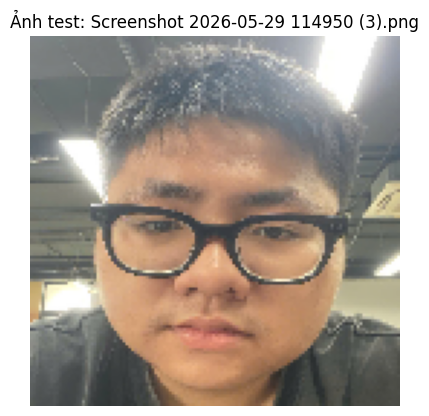

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
------------------------------
Người dự đoán: ĐỖ ĐOÀN CÔNG DANH 
Độ chính xác: 72.62%
------------------------------


In [140]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from google.colab import files # Cần import thêm thư viện này

# 1. Hiển thị nút "Chọn Tệp" để tải ảnh lên máy chủ tạm thời
print("--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---")
uploaded = files.upload()

# 2. Xử lý ảnh vừa tải (Chương trình sẽ tự động lấy tên file ảnh)
if not uploaded:
    print("Bạn chưa tải ảnh nào lên.")
else:
    # Lấy tên của tệp ảnh đầu tiên được tải lên (nếu tải nhiều ảnh một lúc)
    filename = list(uploaded.keys())[0]
    path = filename # Đường dẫn bây giờ chính là tên file

    # 3. Tiền xử lý (Giữ nguyên logic cũ nhưng gọn hơn)
    img_width, img_height = 128, 128 # Đảm bảo kích thước khớp với lúc train

    # Tải ảnh và hiển thị
    img_load = load_img(path, target_size=(img_width, img_height))
    plt.imshow(img_load)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title(f"Ảnh test: {filename}")
    plt.show()

    # Chuẩn hóa ảnh
    img_array = img_to_array(img_load)
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, img_width, img_height, 3)

    # 4. Chạy dự đoán và lấy xác suất cao nhất
    predictions = model.predict(img_array)
    prediction_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100 # Chuyển sang %

    # 5. Ánh xạ loại tới tên người (Yêu cầu `train_generator` phải tồn tại)
    if 'train_generator' in locals() or 'train_generator' in globals():
        class_labels = {v: k for k, v in train_generator.class_indices.items()}
        person_name = class_labels[prediction_index]

        # In kết quả
        print("-" * 30)
        print(f"Người dự đoán: {person_name}")
        print(f"Độ chính xác: {confidence:.2f}%")
        print("-" * 30)
    else:
        print("Lỗi: Không tìm thấy 'train_generator' để lấy nhãn lớp. Đảm bảo bạn đã chạy code huấn luyện trước.")

--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---


Saving 9a109dda-d9bf-4a79-b8d8-fc6ec0302959.jpg to 9a109dda-d9bf-4a79-b8d8-fc6ec0302959 (6).jpg


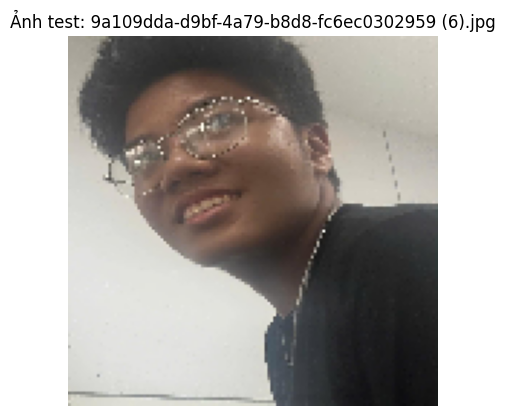

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
------------------------------
Người dự đoán: Trương Nhật Trường Vinh
Độ chính xác: 30.69%
------------------------------


In [143]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from google.colab import files # Cần import thêm thư viện này

# 1. Hiển thị nút "Chọn Tệp" để tải ảnh lên máy chủ tạm thời
print("--- NHẤN VÀO ĐÂY ĐỂ TẢI ẢNH LÊN ---")
uploaded = files.upload()

# 2. Xử lý ảnh vừa tải (Chương trình sẽ tự động lấy tên file ảnh)
if not uploaded:
    print("Bạn chưa tải ảnh nào lên.")
else:
    # Lấy tên của tệp ảnh đầu tiên được tải lên (nếu tải nhiều ảnh một lúc)
    filename = list(uploaded.keys())[0]
    path = filename # Đường dẫn bây giờ chính là tên file

    # 3. Tiền xử lý (Giữ nguyên logic cũ nhưng gọn hơn)
    img_width, img_height = 128, 128 # Đảm bảo kích thước khớp với lúc train

    # Tải ảnh và hiển thị
    img_load = load_img(path, target_size=(img_width, img_height))
    plt.imshow(img_load)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title(f"Ảnh test: {filename}")
    plt.show()

    # Chuẩn hóa ảnh
    img_array = img_to_array(img_load)
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, img_width, img_height, 3)

    # 4. Chạy dự đoán và lấy xác suất cao nhất
    predictions = model.predict(img_array)
    prediction_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100 # Chuyển sang %

    # 5. Ánh xạ loại tới tên người (Yêu cầu `train_generator` phải tồn tại)
    if 'train_generator' in locals() or 'train_generator' in globals():
        class_labels = {v: k for k, v in train_generator.class_indices.items()}
        person_name = class_labels[prediction_index]

        # In kết quả
        print("-" * 30)
        print(f"Người dự đoán: {person_name}")
        print(f"Độ chính xác: {confidence:.2f}%")
        print("-" * 30)
    else:
        print("Lỗi: Không tìm thấy 'train_generator' để lấy nhãn lớp. Đảm bảo bạn đã chạy code huấn luyện trước.")

In [ ]:
# To install a library, use the `!pip install` command followed by the library name.
# For example, to install the 'requests' library, you would run:
# !pip install requests

# If you need to install multiple libraries, you can list them like this:
# !pip install library1 library2

# For specific versions, use '==':
# !pip install pandas==1.5.3

# Uncomment and run the line below to install a hypothetical library:
# !pip install example-library

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can load a file (e.g., a CSV file) by specifying its path. Replace `'path/to/your/file.csv'` with the actual path to your file in Google Drive.

In [ ]:
import pandas as pd

# Example: Load a CSV file from Google Drive
# Replace 'path/to/your/file.csv' with the actual path to your file
file_path = '/content/drive/MyDrive/path/to/your/file.csv'
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Error: The file at /content/drive/MyDrive/path/to/your/file.csv was not found. Please check the path.
